In [ ]:
import pandas as pd
df = pd.read_csv('../data/Nassau Candy Distributor.csv')
df = df[(df['Sales'] > 0) & (df['Units'] > 0)]
df.dropna(subset=['Units', 'Sales', 'Gross Profit'], inplace=True)

In [5]:
import pandas as pd
product_to_factory = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar - Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}
factory_coordinates = {
    "Lot's O' Nuts": {"Factory_Lat": 32.881893, "Factory_Lng": -111.768036},
    "Wicked Choccy's": {"Factory_Lat": 32.076176, "Factory_Lng": -81.088371},
    "Sugar Shack": {"Factory_Lat": 48.11914, "Factory_Lng": -96.18115},
    "Secret Factory": {"Factory_Lat": 41.446333, "Factory_Lng": -90.565487},
    "The Other Factory": {"Factory_Lat": 35.1175, "Factory_Lng": -89.971107}
}
df['Factory'] = df['Product Name'].map(product_to_factory)
df['Factory_Latitude'] = df['Factory'].map(lambda x: factory_coordinates[x]['Factory_Lat'] if pd.notnull(x) else None)
df['Factory_Longitude'] = df['Factory'].map(lambda x: factory_coordinates[x]['Factory_Lng'] if pd.notnull(x) else None)
print(df[['Product Name', 'Factory', 'Factory_Latitude', 'Factory_Longitude']].head())

                        Product Name          Factory  Factory_Latitude  \
0         Wonka Bar - Milk Chocolate  Wicked Choccy's         32.076176   
1  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's         32.076176   
2  Wonka Bar - Nutty Crunch Surprise    Lot's O' Nuts         32.881893   
3     Wonka Bar -Scrumdiddlyumptious              NaN               NaN   
4  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's         32.076176   

   Factory_Longitude  
0         -81.088371  
1         -81.088371  
2        -111.768036  
3                NaN  
4         -81.088371  


In [6]:
df['Gross Margin (%)'] = (df['Gross Profit'] / df['Sales']) * 100
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

In [8]:
product_summary = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).reset_index()
total_sales = product_summary['Sales'].sum()
total_profit = product_summary['Gross Profit'].sum()
total_products = len(product_summary)
product_summary = product_summary.sort_values(by='Sales', ascending=False)
product_summary['Cum_Sales_Pct'] = (product_summary['Sales'].cumsum() / total_sales) * 100
top_revenue_products = product_summary[product_summary['Cum_Sales_Pct'] <= 85]
count_rev_products = len(top_revenue_products)
pct_rev_products = (count_rev_products / total_products) * 100
print(f"Pareto Revenue Analysis: {count_rev_products} out of {total_products} products ({pct_rev_products:.1f}%) generate ~80% of Revenue.")
product_summary = product_summary.sort_values(by='Gross Profit', ascending=False)
product_summary['Cum_Profit_Pct'] = (product_summary['Gross Profit'].cumsum() / total_profit) * 100
top_profit_products = product_summary[product_summary['Cum_Profit_Pct'] <= 85]
count_profit_products = len(top_profit_products)
pct_profit_products = (count_profit_products / total_products) * 100
print(f"Pareto Profit Analysis: {count_profit_products} out of {total_products} products ({pct_profit_products:.1f}%) generate ~80% of Gross Profit.")
df.to_csv('../data/Cleaned_Nassau_Data.csv', index=False)
print("Cleaned data successfully saved to 'data/Cleaned_Nassau_Data.csv'!")

Pareto Revenue Analysis: 4 out of 15 products (26.7%) generate ~80% of Revenue.
Pareto Profit Analysis: 4 out of 15 products (26.7%) generate ~80% of Gross Profit.
Cleaned data successfully saved to 'data/Cleaned_Nassau_Data.csv'!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
df = pd.read_csv('../data/Nassau Candy Distributor.csv')
df = df[(df['Sales'] > 0) & (df['Units'] > 0)].copy()
df['Gross Margin (%)'] = (df['Gross Profit'] / df['Sales']) * 100
df['Profit per Unit'] = df['Gross Profit'] / df['Units']
print("Data initialized successfully! Shape:", df.shape)

Data initialized successfully! Shape: (10194, 20)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22764\248305308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


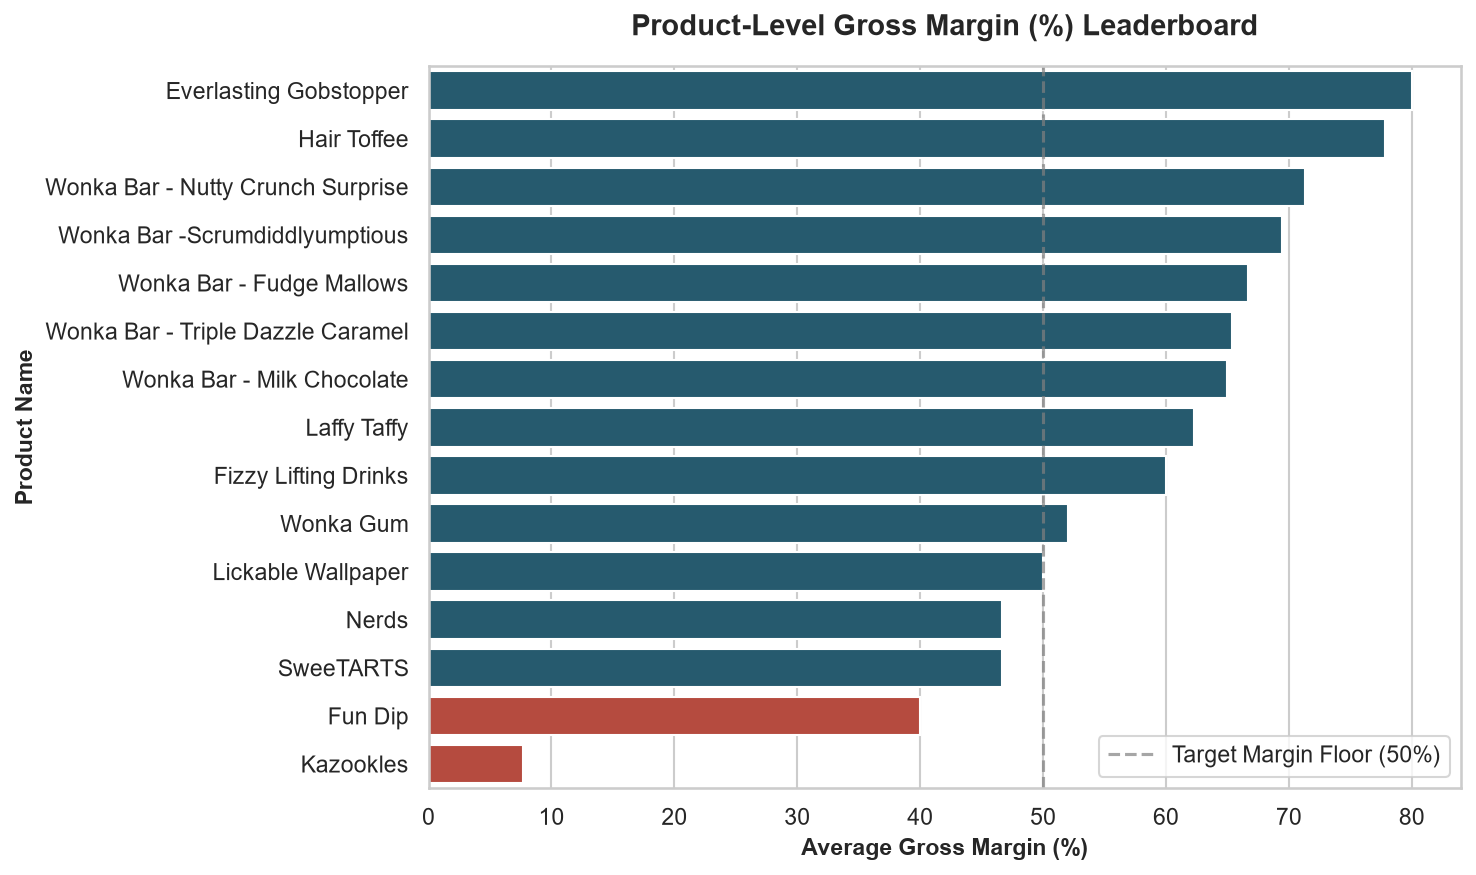

In [11]:
product_margins = df.groupby('Product Name')['Gross Margin (%)'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 6))
colors = ['#1a5f7a' if x > 45 else '#c93b2b' for x in product_margins['Gross Margin (%)']]
sns.barplot(
    data=product_margins, 
    x='Gross Margin (%)', 
    y='Product Name', 
    palette=colors
)
plt.title('Product-Level Gross Margin (%) Leaderboard', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Average Gross Margin (%)', fontsize=11, fontweight='bold')
plt.ylabel('Product Name', fontsize=11, fontweight='bold')
plt.axvline(x=50, color='grey', linestyle='--', alpha=0.7, label='Target Margin Floor (50%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/product_margin_leaderboard.png', bbox_inches='tight')
plt.show()

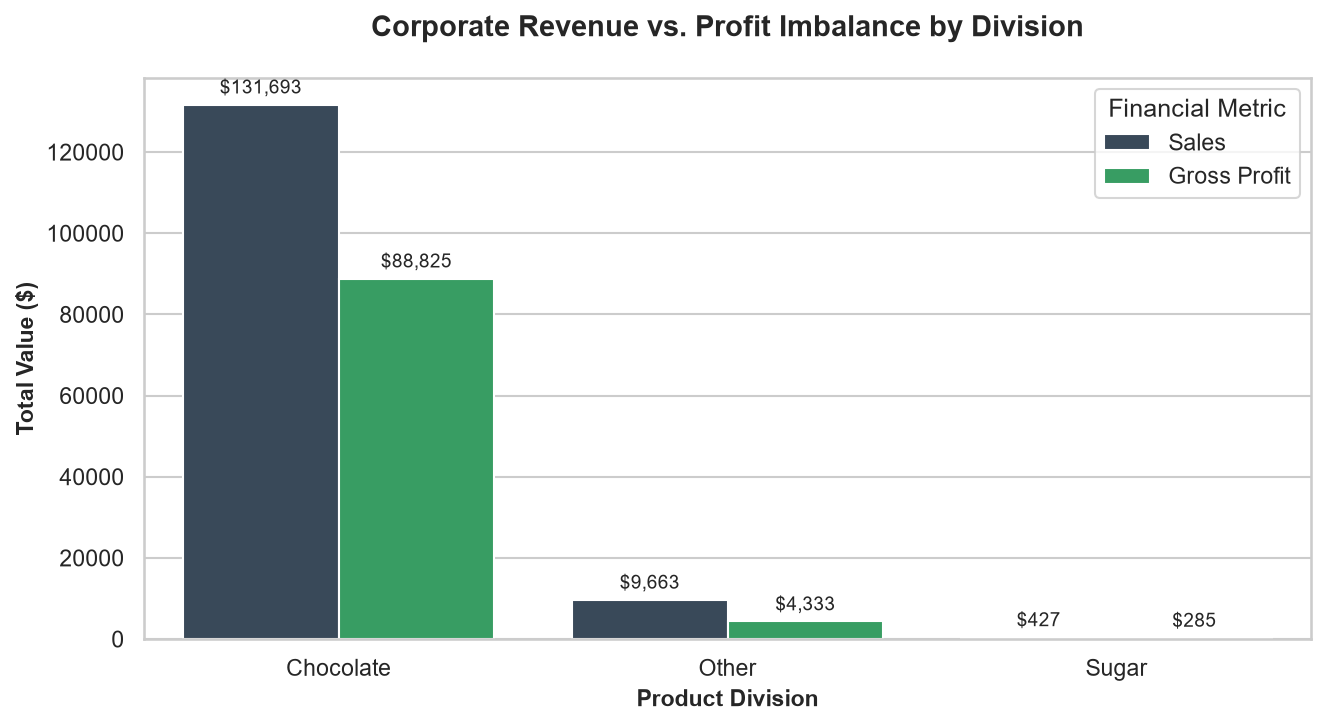

In [13]:
division_perf = df.groupby('Division')[['Sales', 'Gross Profit']].sum().reset_index()
div_melted = pd.melt(division_perf, id_vars=['Division'], value_vars=['Sales', 'Gross Profit'],
                     var_name='Financial Metric', value_name='Amount ($)')
plt.figure(figsize=(9, 5))
sns.barplot(
    data=div_melted, 
    x='Division', 
    y='Amount ($)', 
    hue='Financial Metric', 
    palette=['#34495e', '#27ae60']
)
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"${p.get_height():,.0f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', fontsize=9)
plt.title('Corporate Revenue vs. Profit Imbalance by Division', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Product Division', fontsize=11, fontweight='bold')
plt.ylabel('Total Value ($)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/division_performance.png', bbox_inches='tight')
plt.show()

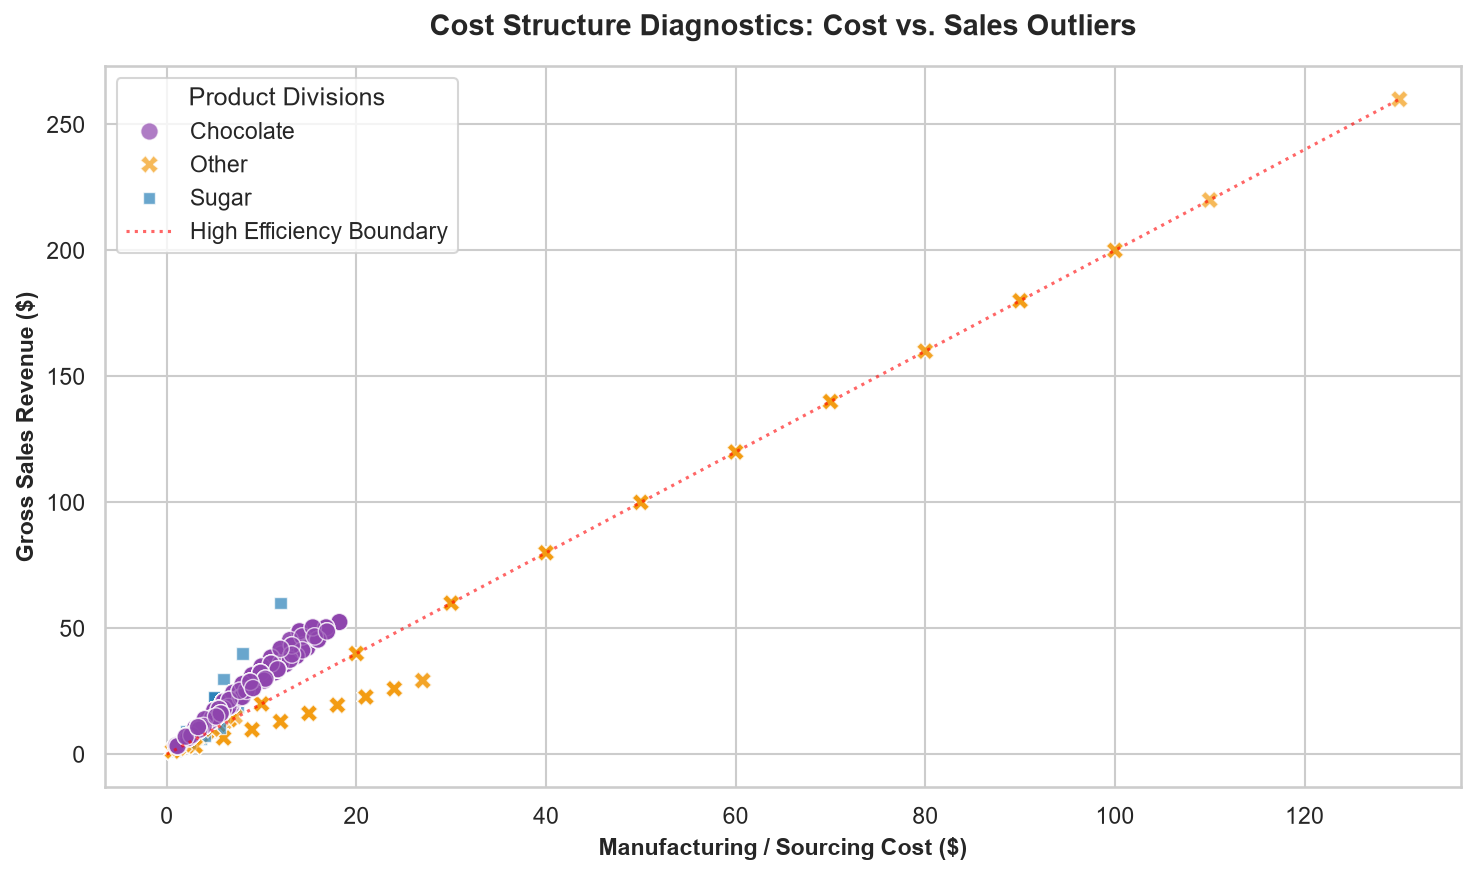

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Cost', 
    y='Sales', 
    hue='Division', 
    style='Division', 
    palette=['#8e44ad', '#f39c12', '#2980b9'], 
    alpha=0.7, 
    s=70
)
max_val = max(df['Cost'].max(), df['Sales'].max())
plt.plot([0, max_val/2], [0, max_val], color='red', linestyle=':', alpha=0.6, label='High Efficiency Boundary')
plt.title('Cost Structure Diagnostics: Cost vs. Sales Outliers', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Manufacturing / Sourcing Cost ($)', fontsize=11, fontweight='bold')
plt.ylabel('Gross Sales Revenue ($)', fontsize=11, fontweight='bold')
plt.legend(title='Product Divisions')
plt.tight_layout()
plt.savefig('../reports/cost_vs_sales_scatter.png', bbox_inches='tight')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22764\1848806625.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


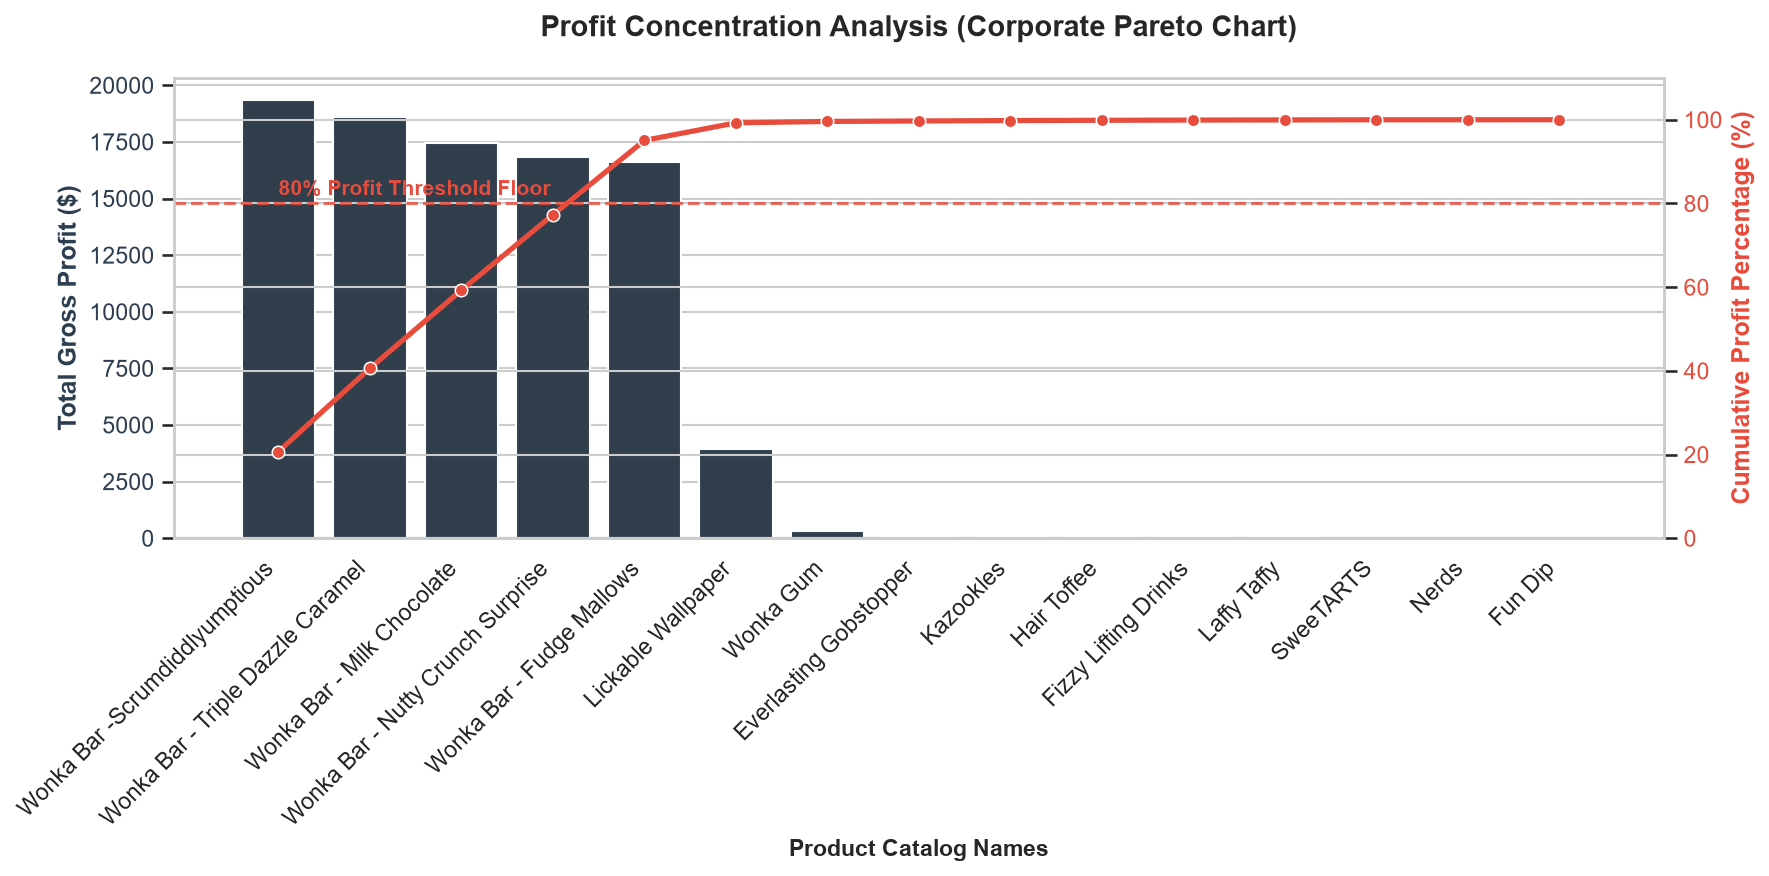

In [15]:
pareto_df = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False).reset_index()
pareto_df['Cum_Percentage'] = (pareto_df['Gross Profit'].cumsum() / pareto_df['Gross Profit'].sum()) * 100
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=pareto_df, x='Product Name', y='Gross Profit', ax=ax1, color='#2c3e50')
ax1.set_ylabel('Total Gross Profit ($)', color='#2c3e50', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax2 = ax1.twinx()
sns.lineplot(data=pareto_df, x='Product Name', y='Cum_Percentage', ax=ax2, color='#e74c3c', marker='o', sort=False, linewidth=2.5)
ax2.set_ylabel('Cumulative Profit Percentage (%)', color='#e74c3c', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, 110)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', alpha=0.8)
ax2.text(0, 82, '80% Profit Threshold Floor', color='#e74c3c', fontweight='bold', fontsize=10)
plt.title('Profit Concentration Analysis (Corporate Pareto Chart)', fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Product Catalog Names', fontsize=11, fontweight='bold')
fig.tight_layout()
plt.savefig('../reports/profit_pareto_concentration.png', bbox_inches='tight')
plt.show()